# 문제정의 

In [ ]:
본 프로젝트의 목표는 Space Titanic 데이터셋을 활용하여 
승객의 정보를 기반으로 생존 여부(Transported)를 예측하는 것이다.

평가 지표는 Accuracy(정확도)이며,
이는 전체 데이터 중 올바르게 예측한 비율을 의미한다.

In [32]:
#라이브러리 불러오기

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [34]:
#데이터 불러오기 /CSV 파일을 불러와 데이터프레임으로 저장/

train = pd.read_csv("train.csv")
test_original = pd.read_csv("test.csv")

train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [35]:
#데이터 확인 /어떤 컬럼에 결측치가 있는지 확인/ 

print(train.info())
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             2

In [37]:
#Feature Engineering
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for df in [train, test_original]:
    df[['Deck','Num','Side']] = df['Cabin'].str.split('/', expand=True)
    df['TotalSpend'] = df[spend_cols].sum(axis=1)

In [39]:
#결측치 처리 

for df in [train, test_original]:
    for col in ['CryoSleep','VIP']:
        df[col] = df[col].fillna(False)
    df['Age'] = df['Age'].fillna(train['Age'].mean())
    for col in ['HomePlanet','Destination','Deck','Side']:
        df[col] = df[col].fillna(train[col].mode()[0])
    df[spend_cols] = df[spend_cols].fillna(0)

/tmp/ipykernel_1410/2612489017.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False)


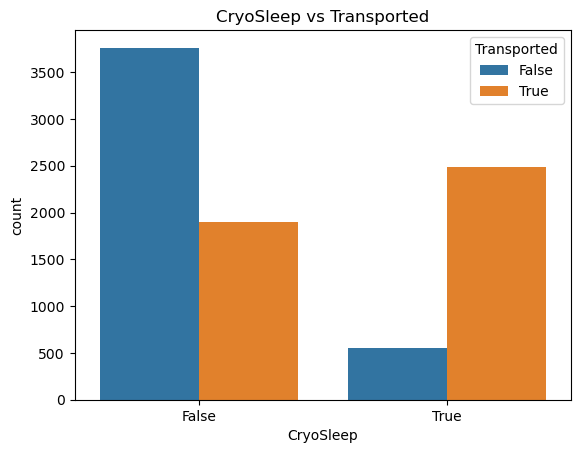

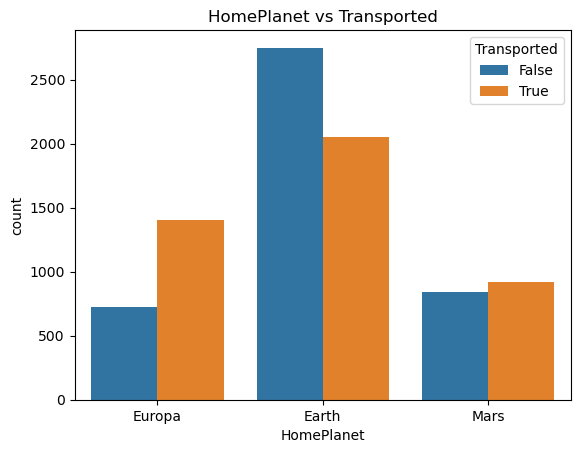

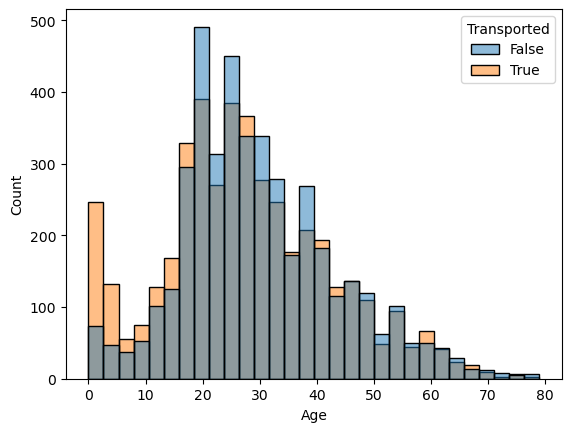

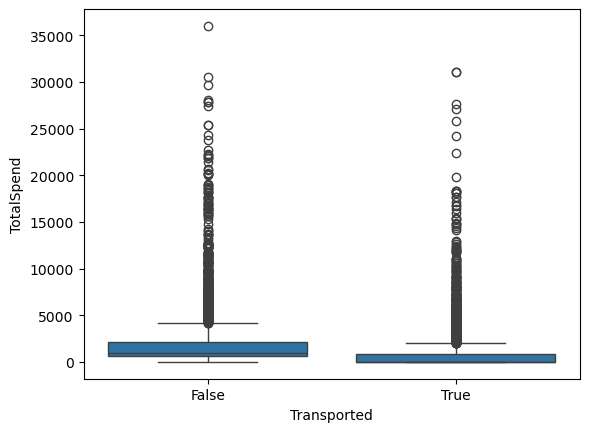

In [41]:
#EDA/시각화/ 

sns.countplot(data=train, x='CryoSleep', hue='Transported')
plt.title("CryoSleep vs Transported")
plt.show()

sns.countplot(data=train, x='HomePlanet', hue='Transported')
plt.title("HomePlanet vs Transported")
plt.show()

sns.histplot(data=train, x='Age', hue='Transported', bins=30)
plt.show()

sns.boxplot(data=train, x='Transported', y='TotalSpend')
plt.show()

In [12]:
#그룹 분석/숫자로 보기/
train.groupby('CryoSleep')['Transported'].mean()

CryoSleep
False    0.335042
True     0.817583
Name: Transported, dtype: float64

In [40]:
#불필요한 컬럼 제거 
train = train.drop(['PassengerId','Name','Cabin'], axis=1)
test = test_original.drop(['PassengerId','Name','Cabin'], axis=1)

In [44]:
# 인코딩
train_features = pd.get_dummies(train.drop('Transported', axis=1))
train_target = train['Transported']
test = pd.get_dummies(test)

In [45]:
# 컬럼 맞추기 

train_features, test = train_features.align(test, join='left', axis=1, fill_value=0)

In [46]:
#모델학습 & 검증 
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(train_features, train_target)

X_train, X_valid, y_train, y_valid = train_test_split(
    train_features, train_target, test_size=0.2, random_state=42
)
model.fit(X_train, y_train)
pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, pred)
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.7860839562967222


In [47]:
# test 예측 
test_pred = model.predict(test)

In [48]:
#제출 파일 생성
submission = pd.DataFrame({
    "PassengerId": test_original["PassengerId"],
    "Transported": test_pred
})
submission.to_csv("submission.csv", index=False)
print("submission.csv 파일 생성 완료 ✅")

submission.csv 파일 생성 완료 ✅


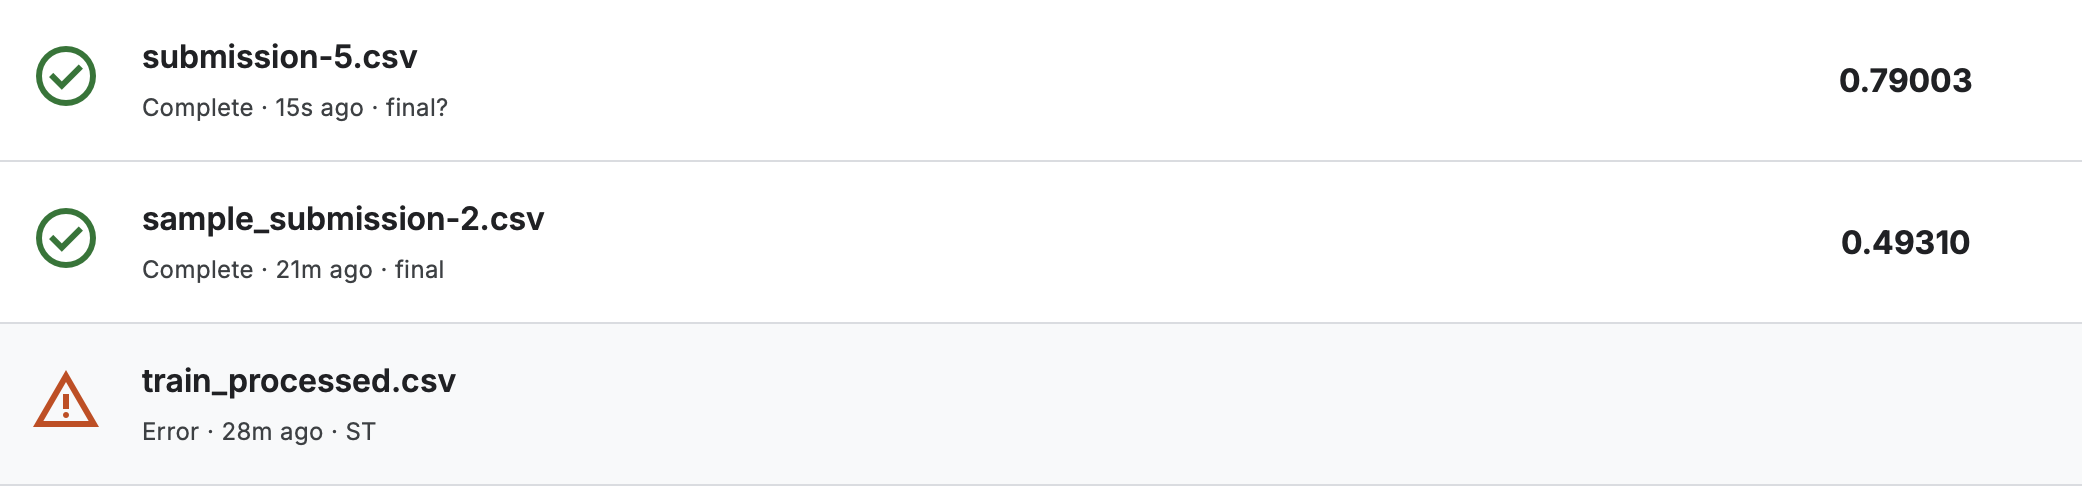